In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [3]:
ticker = 'AAPL'
df = yf.download(ticker, start='2020-01-01', end='2024-01-01')

print(f" {ticker} Stock Data Loaded!")
print(f"Shape: {df.shape}")
print(df.head())
print(df.info())
print(df.describe())

[*********************100%***********************]  1 of 1 completed

 AAPL Stock Data Loaded!
Shape: (1006, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400528  72.460791  71.156689  71.409793  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267914  72.306483  70.568488  70.819186  118387200
2020-01-07  71.928062  72.533103  71.708703  72.277586  108872000
2020-01-08  73.085114  73.386431  71.631559  71.631559  132079200
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1006 non-null   float64
 1   (High, AAPL)    1006 non-null   float64
 2   (Low, AAPL)     1006 non-null   float64
 3   (Open, AAPL)    1006 non-null   float64
 4   (Volume, AAPL)  1006 non-null  

In [4]:
df.dropna(inplace=True)

# Target: Next day's closing price
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# Features & Target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

print(f"\n✅ Features: {X.columns.tolist()}")
print(f"✅ Target: Next Day Close Price")


✅ Features: [('Open', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Volume', 'AAPL')]
✅ Target: Next Day Close Price


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"\n✅ Train Size: {X_train.shape}")
print(f"✅ Test  Size: {X_test.shape}")


✅ Train Size: (804, 4)
✅ Test  Size: (201, 4)


In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n✅ Models Trained!")


✅ Models Trained!


In [7]:
def evaluate(name, y_test, y_pred):
    print(f"\n📊 {name}")
    print(f"   MAE : {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"   R²  : {r2_score(y_test, y_pred):.4f}")

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest",     y_test, rf_pred)


📊 Linear Regression
   MAE : 1.6542
   R²  : 0.9579

📊 Random Forest
   MAE : 7.5027
   R²  : 0.0884


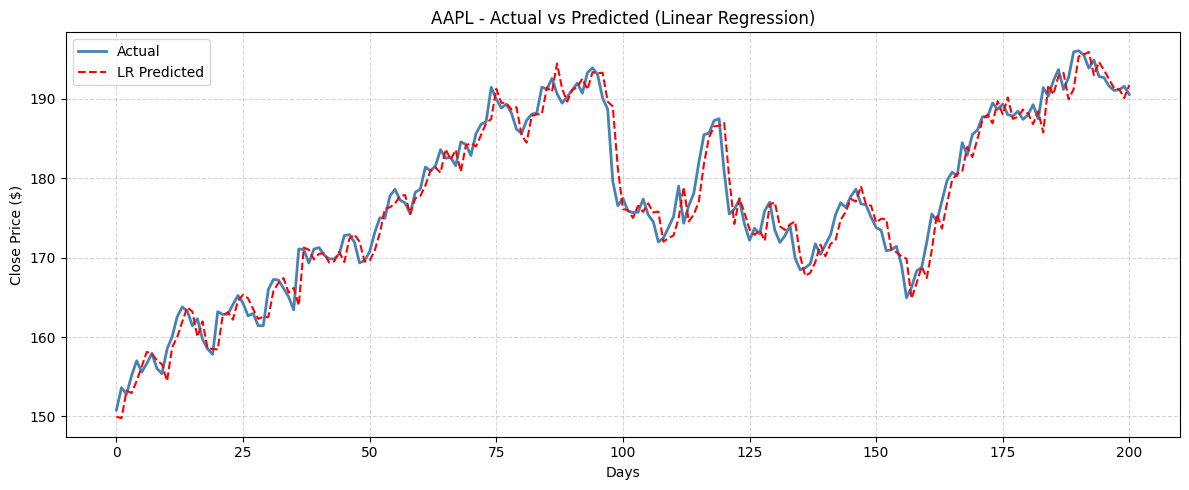

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual',     color='steelblue', linewidth=2)
plt.plot(lr_pred,       label='LR Predicted', color='red',    linewidth=1.5, linestyle='--')
plt.title(f'{ticker} - Actual vs Predicted (Linear Regression)')
plt.xlabel('Days')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

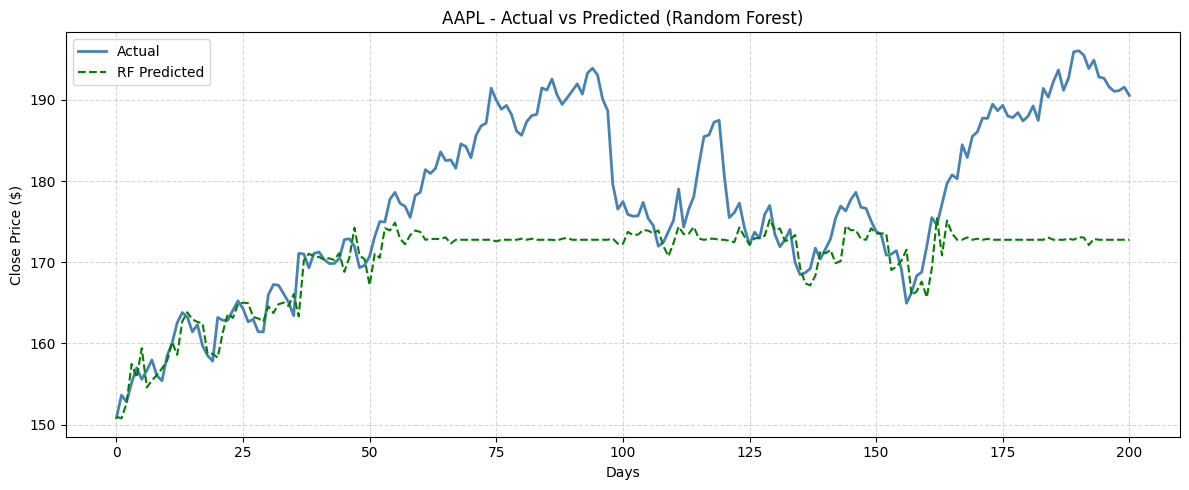

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual',     color='steelblue', linewidth=2)
plt.plot(rf_pred,       label='RF Predicted', color='green',  linewidth=1.5, linestyle='--')
plt.title(f'{ticker} - Actual vs Predicted (Random Forest)')
plt.xlabel('Days')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

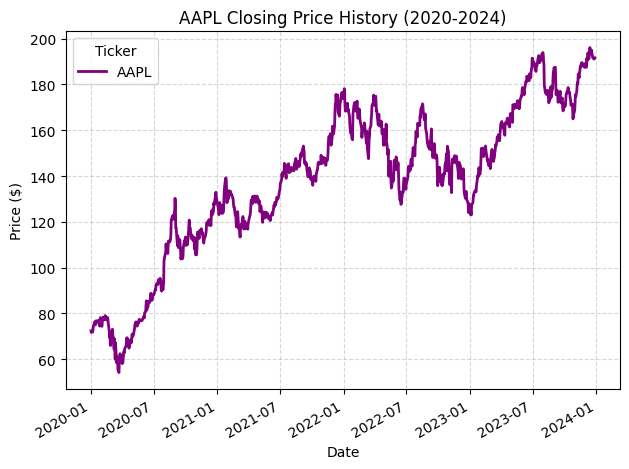

In [10]:
plt.figure(figsize=(12, 5))
df['Close'].plot(color='purple', linewidth=2)
plt.title(f'{ticker} Closing Price History (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

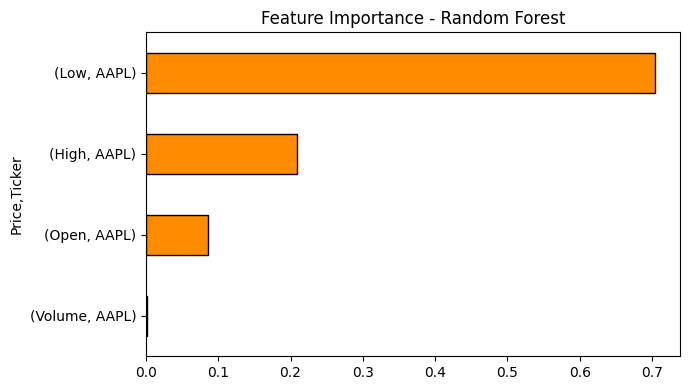

In [11]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
plt.figure(figsize=(7, 4))
feat_imp.sort_values().plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()